## 🏝️ Taylor 2023

**Concepts:** [Warm-starting](../routers.md#warm-starting) · [Crossings & detours](../problem.md#crossings-contours-and-detours) **Network/Router API:** [🏝️ Taylor 2023](hi40_example_taylor_2023.ipynb)

Routing the cables of a wind farm location with 122 turbines and 2 substations, which has a concave cable-laying area and one obstacle within that area.

Additional complexity in the geometry of the location has negligible impact on the solving time, as it does not increase the number of variables in the MILP model.

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.svg import svgplot
from optiwindnet.interarraylib import G_from_S, as_normalized
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.heuristics import constructor
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.MILP import solver_factory, ModelOptions

### Solvers

Using a MILP solver can produce better solutions. This notebook uses COIN-OR CBC; the other supported solvers, and which of them are commercial, are listed in [Supported solvers](../reference/solvers.md#supported-solvers).

### Load input data

In [2]:
locations = load_repository()

Using example location from <https://onlinelibrary.wiley.com/doi/abs/10.1049/rpg2.12593>.

In [3]:
L = locations.taylor_2023

Note: To view SVG cell outputs, trust this notebook first.

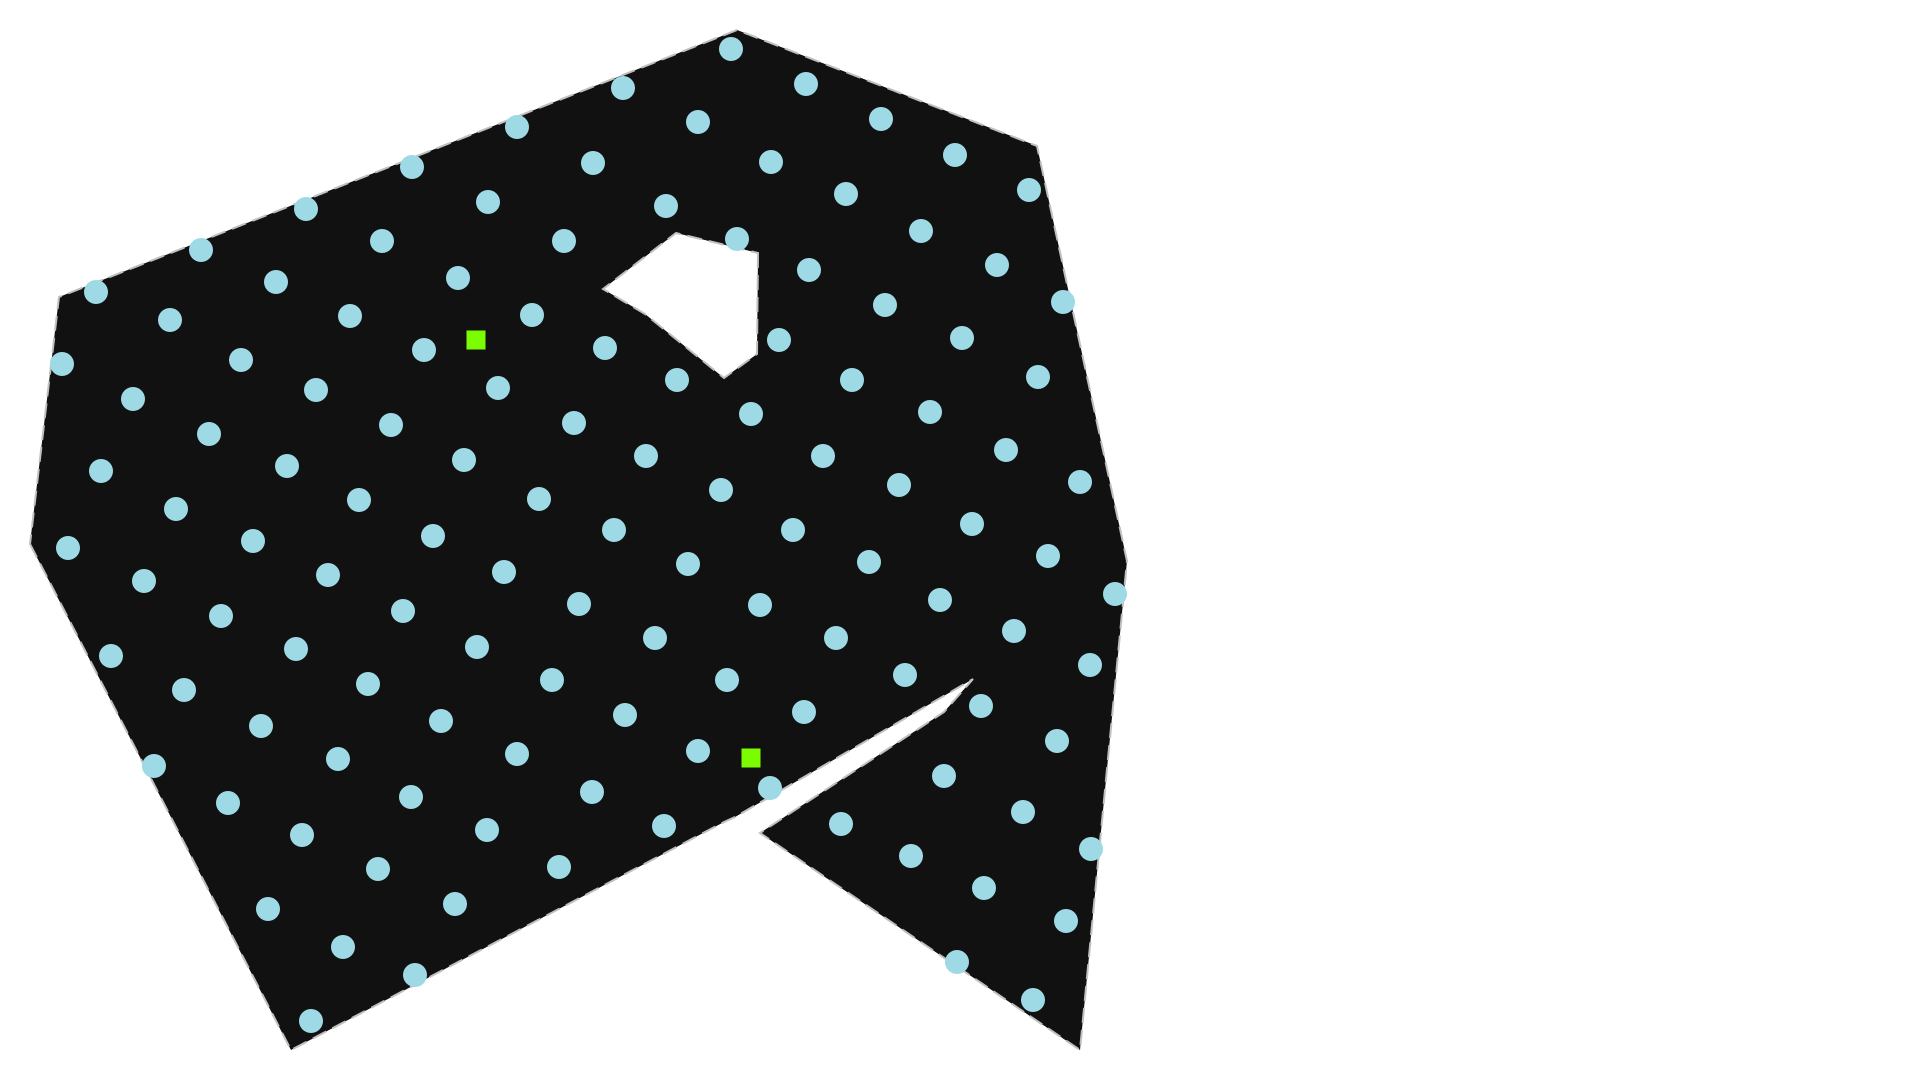

In [4]:
svgplot(L)

There are two options for generating an initial solution to warm-start the MILP solver: the heuristic [constructor()](../autoapi/optiwindnet/heuristics/index.rst#optiwindnet.heuristics.constructor) or the meta-heuristic [hgs_cvrp()](../autoapi/optiwindnet/baselines/hgs/index.rst#optiwindnet.baselines.hgs.hgs_cvrp). Which of them is eligible depends on the model being started — see [Warm-starting](../routers.md#warm-starting).

### Generate the warm-start solution

In [5]:
P, A = make_planar_embedding(L)

#### Constructor biased_EW

In [6]:
S_pre = constructor(A, capacity=8)

In [7]:
G_pre = G_from_S(S_pre, A)

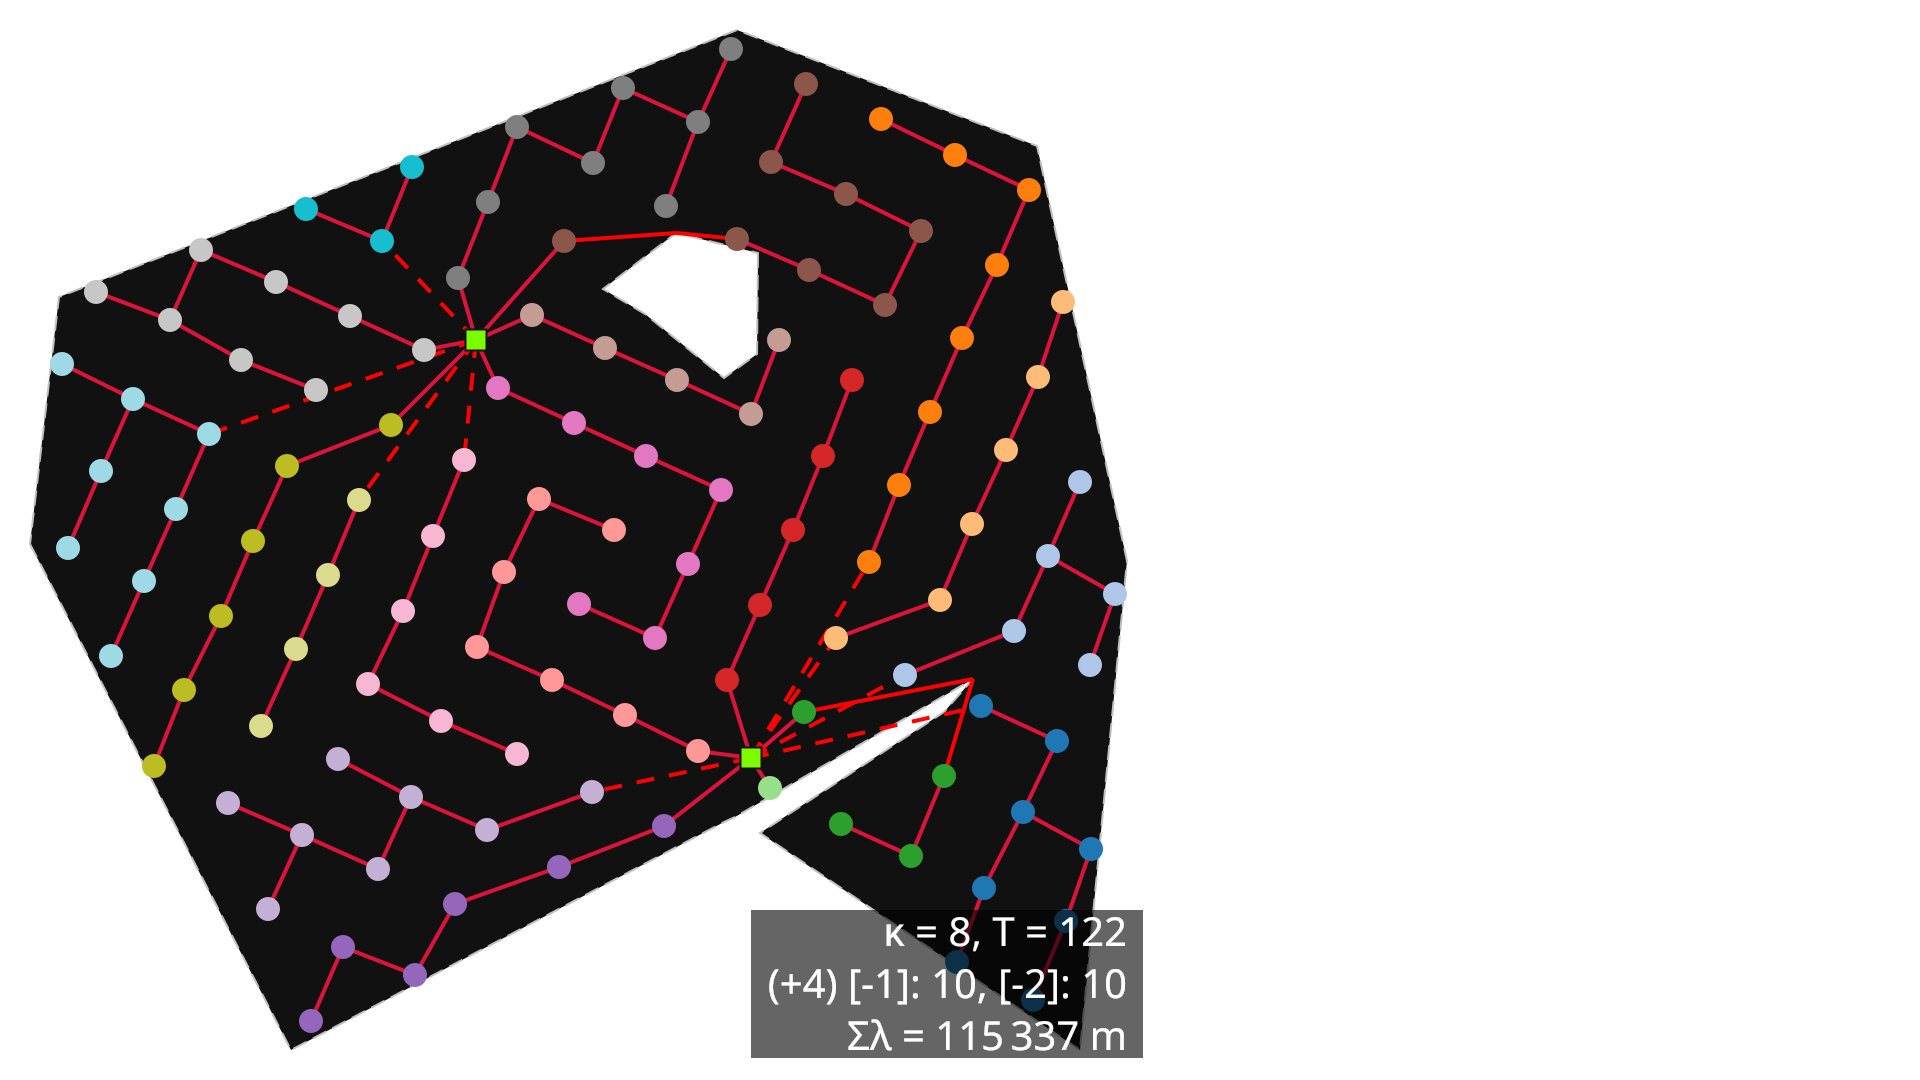

In [8]:
svgplot(G_pre)

#### hgs_cvrp

It is recommended to normalize A before passing it to the HGS meta-heuristic.

In [9]:
S_hgs = hgs_cvrp(as_normalized(A), capacity=8, time_limit=1)

In [10]:
G_hgs = G_from_S(S_hgs, A)

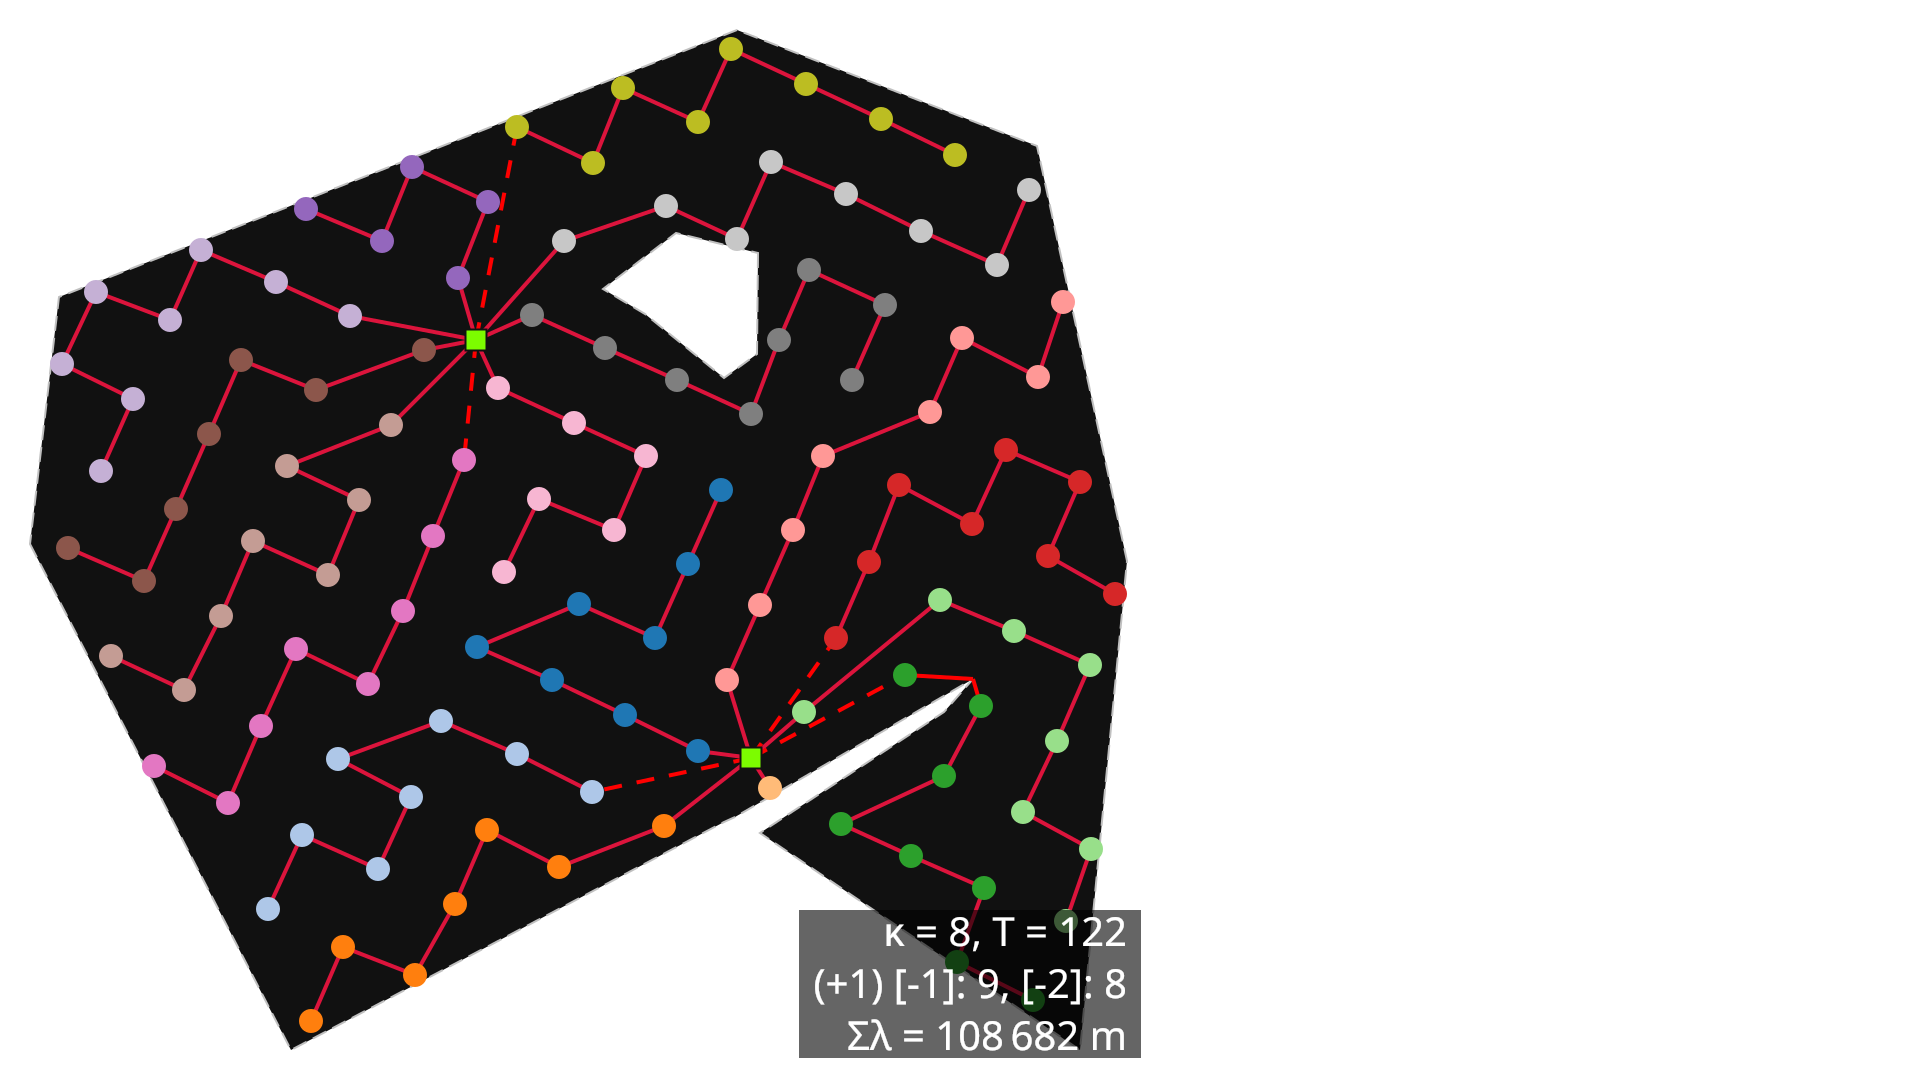

In [11]:
svgplot(G_hgs)

### Detouring the feeder cables

When warm-starting the MILP solver, there should be no detours, as is the case in **G_pre** and **G_hgs**. This section can be skipped.

On the other hand, to use one of these as a final routeset without using the MILP solver, one should add detours to the feeder cables that have forbidden crossings:

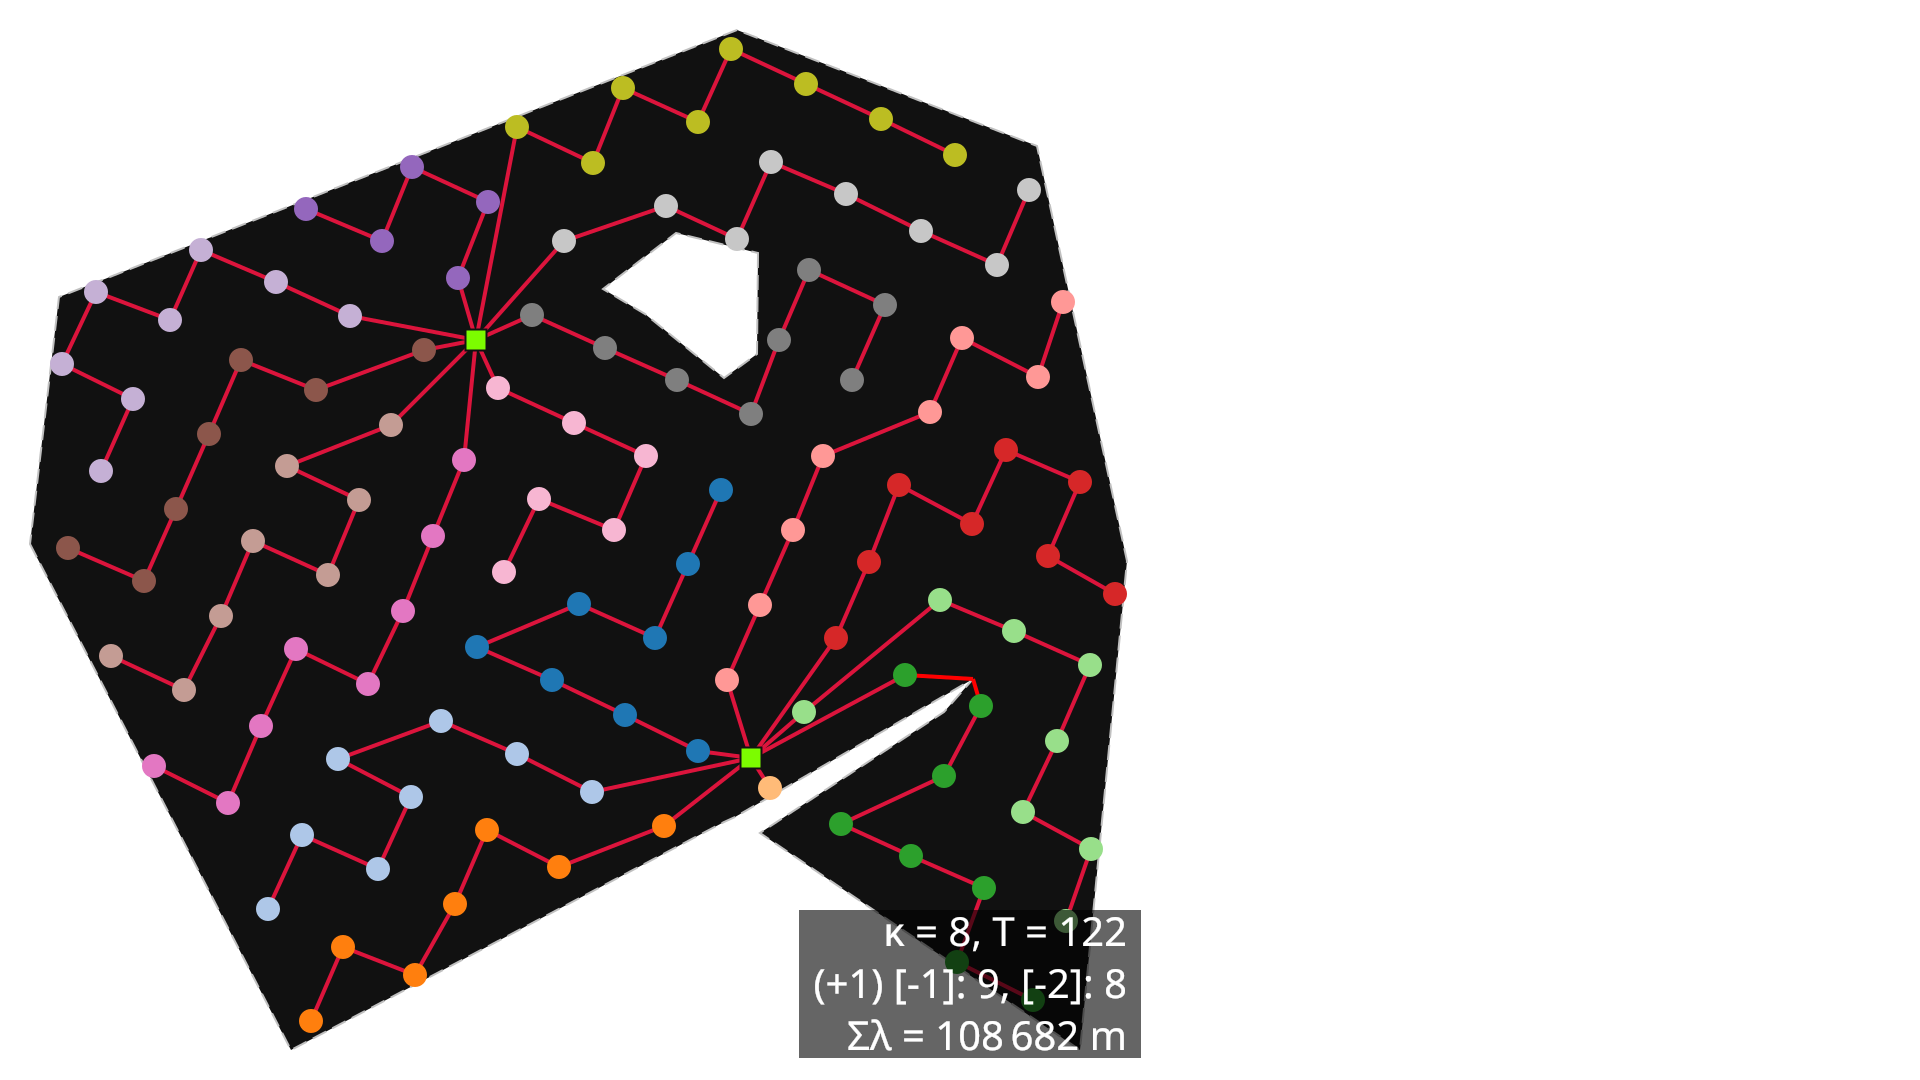

In [12]:
H_hgs = PathFinder(G_hgs, planar=P, A=A).create_detours()
svgplot(H_hgs)

### Create MILP model and optimize it using COIN-OR Branch and Cut (CBC)

In [13]:
solver = solver_factory('cbc')

In [14]:
solver.set_problem(
    P, A,
    capacity=S_hgs.graph['capacity'],
    model_options=ModelOptions(
        topology="branched",
        feeder_route="segmented",
        feeder_limit="unlimited",
    ),
    warmstart=S_hgs,
)

In [15]:
# the parameters below and more can be experimented with
# http://www.decom.ufop.br/haroldo/files/cbcCommandLine.pdf
solver.options

{'threads': 8,
 'timeMode': 'elapsed',
 'nodeStrategy': 'downFewest',
 'Dins': 'on',
 'VndVariableNeighborhoodSearch': 'on',
 'Rens': 'on',
 'Rins': 'on',
 'pivotAndComplement': 'off',
 'proximitySearch': 'off',
 'gomoryCuts': 'on',
 'mixedIntegerRoundingCuts': 'on',
 'flowCoverCuts': 'on',
 'cliqueCuts': 'off',
 'twoMirCuts': 'off',
 'knapsackCuts': 'off',
 'probingCuts': 'off',
 'zeroHalfCuts': 'off',
 'liftAndProjectCuts': 'off',
 'residualCapacityCuts': 'off'}

In [16]:
solver.solve(
    mip_gap=0.005,
    time_limit=400,
    verbose=True,
    options=dict( # these are in addition to the default solver.options
        # if repeatable results are desired, set the seed
        RandomCbcSeed=1234567,
        # CBC works better if the number threads is set to the number of physical cores
        threads=8,
    )
)

Welcome to the CBC MILP Solver 
Version: 2.10.13 
Build Date: Apr  1 2026 

command line - /usr/bin/cbc -threads 8 -timeMode elapsed -nodeStrategy downFewest -Dins on -VndVariableNeighborhoodSearch on -Rens on -Rins on -pivotAndComplement off -proximitySearch off -gomoryCuts on -mixedIntegerRoundingCuts on -flowCoverCuts on -cliqueCuts off -twoMirCuts off -knapsackCuts off -probingCuts off -zeroHalfCuts off -liftAndProjectCuts off -residualCapacityCuts off -RandomCbcSeed 1234567 -seconds 400 -ratioGap 0.005 -printingOptions all -import /home/masoda/tmp/tmpu81cr38u.pyomo.lp -mipstart /home/masoda/tmp/tmp6t5_9nm7.cbc.soln -stat=1 -solve -solu /home/masoda/tmp/tmpu81cr38u.pyomo.soln (default strategy 1)
threads was changed from 0 to 8
Option for timeMode changed from cpu to elapsed
Option for nodeStrategy changed from fewest to downfewest
Option for Dins changed from off to on
Option for VndVariableNeighborhoodSearch changed from off to on
Option for Rens changed from off to on
Option for

SolutionInfo(runtime=400.23, bound=105107.74, objective=108124.57598705, relgap=0.02790148270649706, termination='maxTimeLimit')

### Trace routes from solution topology

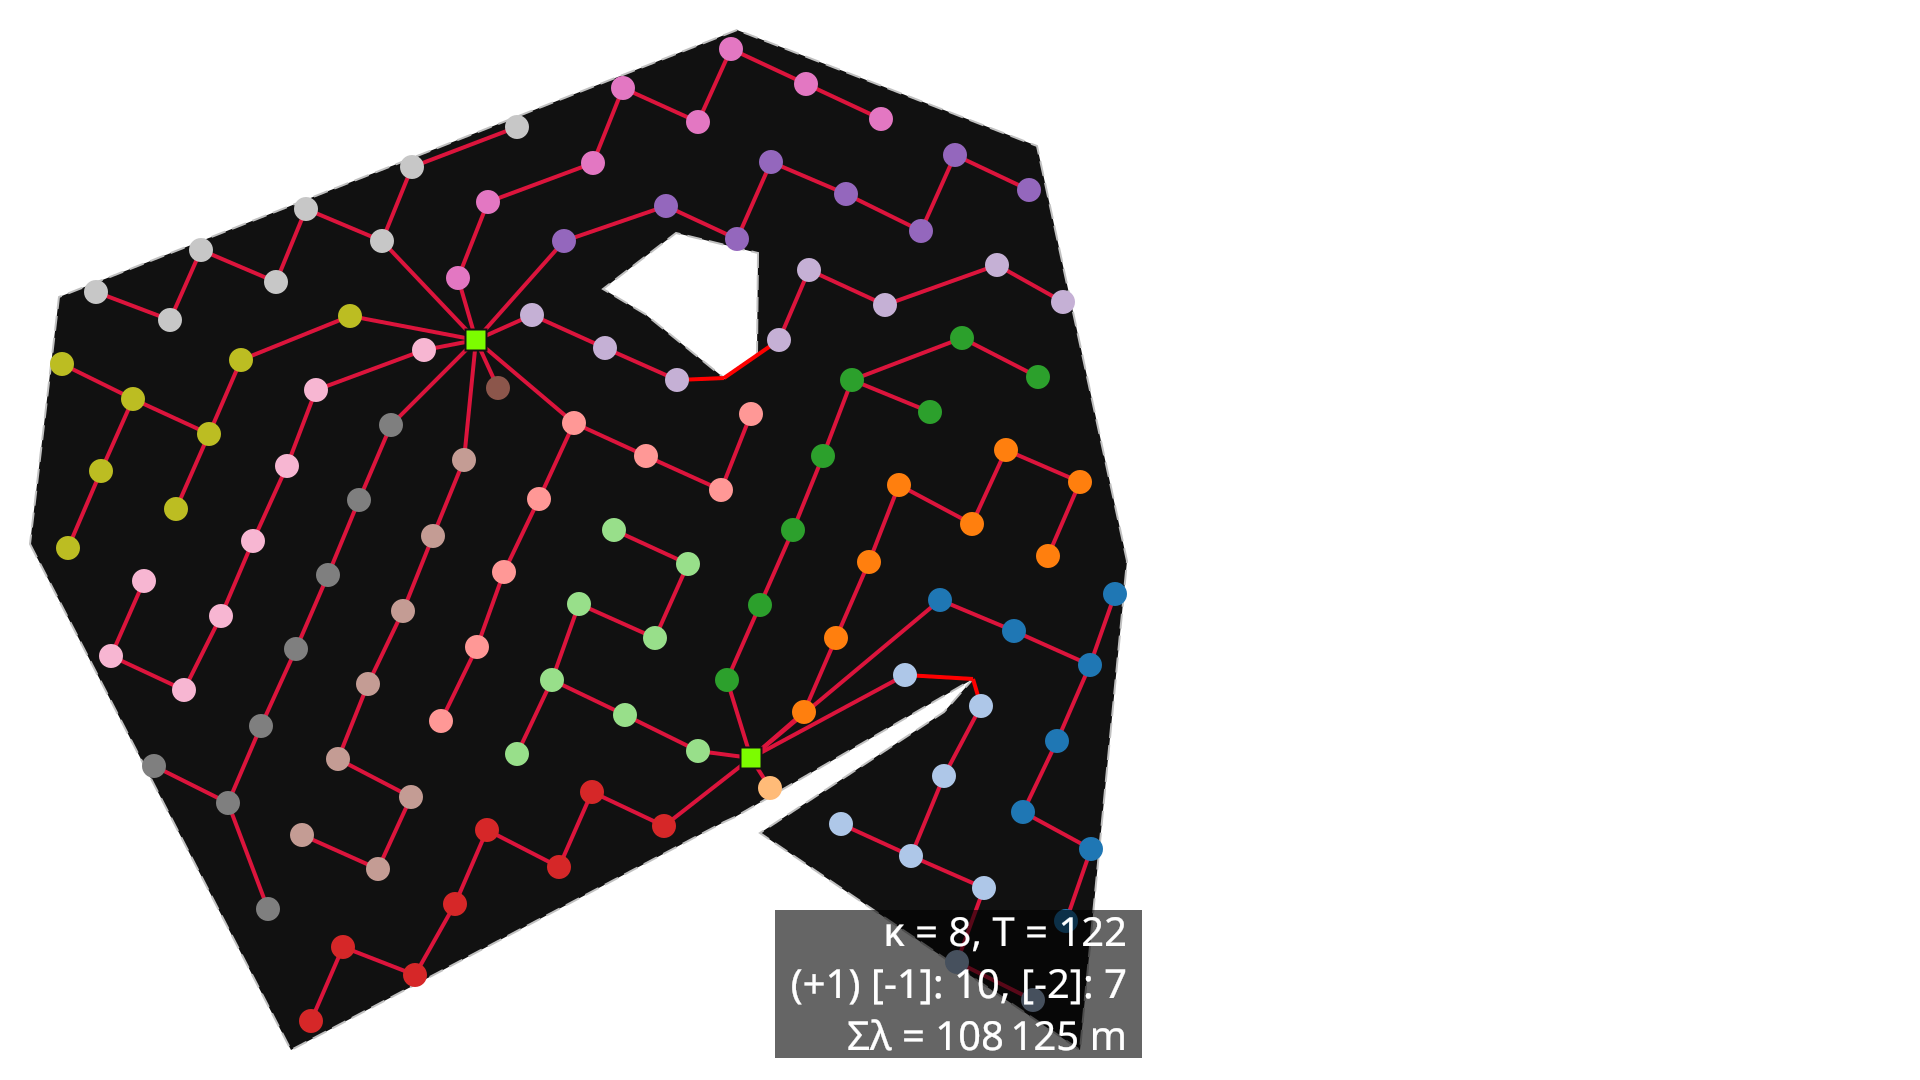

In [17]:
S, G = solver.get_solution()
svgplot(G)